In [1]:
import json
import numpy as np
import os

from datasets import load_dataset
from rouge_score import rouge_scorer

# ref/cand
rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

In [2]:
model_map_name = {
    "qwen": "Qwen2",
    "Mistral-7B-Instruct-v0.3": "Mistral v0.3",
    "gemma-7b-it": "Gemma 1.1",
    "gemma-1.1-7b-it": "Gemma 1.1",
    "Meta-Llama-3-8B-Instruct": "Llama 3",
    "llama3.1": "Llama 3.1",
    "led_tiny": "LED-Tiny",
    "primera_tiny": "Primera-Tiny",
    "led_short": "LED-Short",
    "primera_short": "Primera-Short",
    "led_long": "LED-Long",
    "primera_long": "Primera-Long"
}

pipeline_map_name = {
    "first5last5_bert": "F5L5 + BES" ,
    "first5last5_textrank": "F5L5 + TR", 
    "first5last5": "F5L5",
    "random_selection_bert": "RS + BES",
    "random_selection_textrank": "RS + TR",
    "random_selection": "RS",
    "None": "None"
}
datasets = ["multilex_tiny", "multilex_short", "multilex_long", "eurlexsum"]
models = [
    "gemma-1.1-7b-it",
    "Meta-Llama-3-8B-Instruct",
    "Mistral-7B-Instruct-v0.3",
    "llama3.1",
    "qwen"
]
selections = [
    "first5last5_bert",
    "first5last5_textrank",
    "random_selection_bert",
    "random_selection_textrank"
]

datasets = ["multilex_tiny", "multilex_short", "multilex_long", "eurlexsum_test", "eurlexsum_validation"]

In [3]:
def load_data(dataset):
    data= None
    split = None
    match dataset:
        case "multilex_tiny":
            data = load_dataset("allenai/multi_lexsum", name="v20230518")["test"].filter(lambda x: x["summary/tiny"] != None)["summary/tiny"]
        case "multilex_short":
            data = load_dataset("allenai/multi_lexsum", name="v20230518")["test"].filter(lambda x: x["summary/short"] != None)["summary/short"]
        case "multilex_long":
            data = load_dataset("allenai/multi_lexsum", name="v20230518")["test"].filter(lambda x: x["summary/long"] != None)["summary/long"]
        case "eurlexsum":
            data = load_dataset("dennlinger/eur-lex-sum", "english")
            data = data["train"]["summary"] + data["test"]["summary"] + data["validation"]["summary"]
        case "eurlexsum_test":
            data = load_dataset("dennlinger/eur-lex-sum", "english")
            split = slice(len(data["train"]["summary"]), len(data["train"]["summary"] + data["test"]["summary"]))
            data = data["test"]["summary"]
        case "eurlexsum_validation":
            data = load_dataset("dennlinger/eur-lex-sum", "english")
            split = slice(len(data["train"]["summary"] + data["test"]["summary"]), len(data["train"]["summary"] + data["test"]["summary"] + data["validation"]["summary"]))
            data = data["validation"]["summary"]
        case "eurlexsum":
            data = load_dataset("dennlinger/eur-lex-sum", "english")
            split = slice(0,len(data["train"]["summary"] + data["test"]["summary"] + data["validation"]["summary"]))
            data = data["train"]["summary"] + data["test"]["summary"] + data["validation"]["summary"]

    return data, split

In [60]:
from tqdm import tqdm
global_stats = {}
for dataset in datasets[:]:
    if "eurlexsum" in dataset:
        path = os.path.join("answers", "eurlexsum")
    else:
        path = os.path.join("answers", dataset)

    for model in tqdm(os.listdir(path), desc=dataset):
        if "mixtral" in model:
            continue
        if ("llama3.1" in model or "qwen" in model):
            continue
        path = os.path.join(path, model)
        for prompt_type in os.listdir(path):
            path = os.path.join(path, prompt_type)
            for selection_type in os.listdir(path):
                path = os.path.join(path, selection_type)
                llm_answers = []
                files = os.listdir(path)
                files = sorted(files, key = lambda x: int(x.split(".")[0]))
                for file in files:
                    text = json.load(open(path + "/" + file, "r"))[-1]["content"]
                    llm_answers += [text]
                scores = {
                    "rouge1":{
                        "precision":[],
                        "recall":[],
                        "fmeasure":[]
                    },
                    "rouge2":{
                        "precision":[],
                        "recall":[],
                        "fmeasure":[]
                    },
                    "rougeL":{
                        "precision":[],
                        "recall":[],
                        "fmeasure":[]
                    }
                }
                data, split = load_data(dataset)
                if split:
                    llm_answers = llm_answers[split]
                for (ref, cand) in zip(data, llm_answers):
                    score = rouge.score(ref, cand)
                    scores["rouge1"]["precision"] += [score["rouge1"][0]]
                    scores["rouge1"]["recall"] += [score["rouge1"][1]]
                    scores["rouge1"]["fmeasure"] += [score["rouge1"][2]]

                    scores["rouge2"]["precision"] += [score["rouge2"][0]]
                    scores["rouge2"]["recall"] += [score["rouge2"][1]]
                    scores["rouge2"]["fmeasure"] += [score["rouge2"][2]]

                    scores["rougeL"]["precision"] += [score["rougeL"][0]]
                    scores["rougeL"]["recall"] += [score["rougeL"][1]]
                    scores["rougeL"]["fmeasure"] += [score["rougeL"][2]]
                
                if "eurlexsum" in dataset:
                    path_aux = path.replace("eurlexsum", dataset)
                    global_stats[path_aux[8:]] = scores
                global_stats[path[8:]] = scores
                path, _ = os.path.split(path)
            path, _ = os.path.split(path)
        path, _ = os.path.split(path)
    path, _ = os.path.split(path)

for dataset in datasets[:]:
    # if "eurlexsum" in dataset:
    #     path = os.path.join("answers", "eurlexsum")
    # else:
    path = os.path.join("answers", dataset)

    for model in tqdm(os.listdir(path), desc=dataset):
        if "mixtral" in model:
            continue
        if not("llama3.1" in model or "qwen" in model):
            continue
        path = os.path.join(path, model)
        for prompt_type in os.listdir(path):
            path = os.path.join(path, prompt_type)
            llm_answers = []
            files = os.listdir(path)
            files = sorted(files, key = lambda x: int(x.split(".")[0]))
            for file in files:
                if "qwen" in model:
                    text = json.load(open(path + "/" + file, "r"))["conversation"]["content"]
                else:
                    text = json.load(open(path + "/" + file, "r"))[-1]["content"]
                llm_answers += [text]

            scores = {
                "rouge1":{
                    "precision":[],
                    "recall":[],
                    "fmeasure":[]
                },
                "rouge2":{
                    "precision":[],
                    "recall":[],
                    "fmeasure":[]
                },
                "rougeL":{
                    "precision":[],
                    "recall":[],
                    "fmeasure":[]
                }
            }
            data, split = load_data(dataset)
            # if split:
            #     llm_answers = llm_answers[split]
            
            for (ref, cand) in zip(data, llm_answers):
                score = rouge.score(ref, cand)
                scores["rouge1"]["precision"] += [score["rouge1"][0]]
                scores["rouge1"]["recall"] += [score["rouge1"][1]]
                scores["rouge1"]["fmeasure"] += [score["rouge1"][2]]

                scores["rouge2"]["precision"] += [score["rouge2"][0]]
                scores["rouge2"]["recall"] += [score["rouge2"][1]]
                scores["rouge2"]["fmeasure"] += [score["rouge2"][2]]

                scores["rougeL"]["precision"] += [score["rougeL"][0]]
                scores["rougeL"]["recall"] += [score["rougeL"][1]]
                scores["rougeL"]["fmeasure"] += [score["rougeL"][2]]
            
            if "eurlexsum" in dataset:
                dataset_idx_in_path = path.find(dataset) 
                path_aux = path[dataset_idx_in_path:dataset_idx_in_path+len(dataset)] + "/" + path[dataset_idx_in_path+len(dataset)*2+2:]
                global_stats[path_aux] = scores
            global_stats[path[8:]] = scores
            path, _ = os.path.split(path)
        path, _ = os.path.split(path)
    path, _ = os.path.split(path)


eurlexsum_validation: 100%|██████████| 2/2 [01:51<00:00, 55.93s/it]


In [61]:
import pickle

pickle.dump(global_stats, open("rouge_breakdown_all.pickle", "wb"))

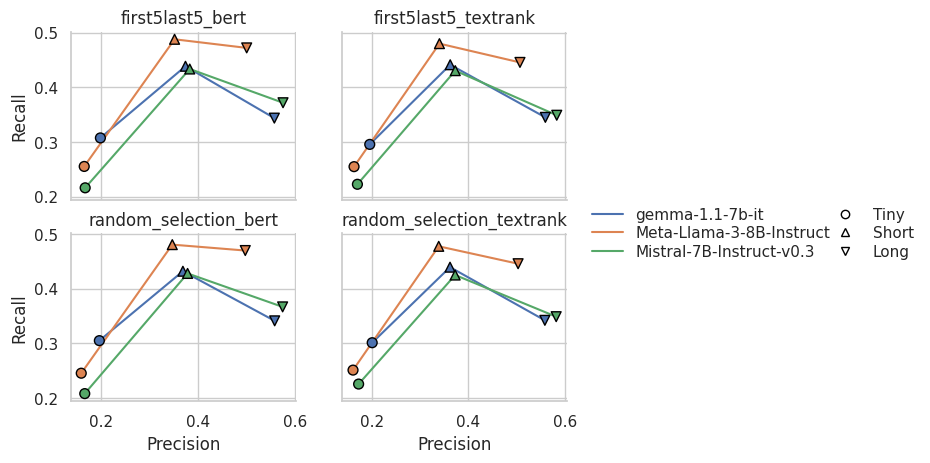

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

sns.set_theme(style="whitegrid")

models = [
    "gemma-1.1-7b-it",
    "Meta-Llama-3-8B-Instruct",
    "Mistral-7B-Instruct-v0.3",
    
]
selections = [
    "first5last5_bert",
    "first5last5_textrank",
    "random_selection_bert",
    "random_selection_textrank"
]
dfs = []
text_pos = []
for model in models:
    for selection in selections:
        llm_vals_tiny = global_stats[f"multilex_tiny/{model}/basic/{selection}"]["rouge1"]
        llm_vals_short = global_stats[f"multilex_short/{model}/basic/{selection}"]["rouge1"]
        llm_vals_long = global_stats[f"multilex_long/{model}/basic/{selection}"]["rouge1"]

        x = [
            np.mean(llm_vals_tiny["precision"]),
            np.mean(llm_vals_short["precision"]),
            np.mean(llm_vals_long["precision"])
        ]
        y = [
            np.mean(llm_vals_tiny["recall"]),
            np.mean(llm_vals_short["recall"]),
            np.mean(llm_vals_long["recall"])
        ]

        dfs += [pd.DataFrame({
            "Precision": x,
            "Recall": y,
            "Dataset": ["Tiny", "Short", "Long"],
            "Model": [model] * 3,
            "Selection": [selection] * 3
        })]

        text_pos += [{
            "x": x,
            "y": y,
            "Dataset": ["Tiny", "Short", "Long"]
        }]

fig, axes = plt.subplots(2,2,sharex=True,sharey=True)
axes = axes.flatten()
a_orig = pd.concat(dfs)
for ax, selection in zip(axes, selections):
    a = a_orig[a_orig["Selection"] == selection]
    sns.scatterplot(data=a[a["Dataset"] == "Tiny"], x="Precision", y="Recall", hue="Model", marker="o", legend=False, s=50, zorder=10, edgecolor="black", linewidth=1, ax=ax)
    sns.scatterplot(data=a[a["Dataset"] == "Short"], x="Precision", y="Recall", hue="Model", marker="^", legend=False, s=50, zorder=10, edgecolor="black", linewidth=1, ax=ax)
    sns.scatterplot(data=a[a["Dataset"] == "Long"], x="Precision", y="Recall", hue="Model", marker="v", legend=False, s=50, zorder=10, edgecolor="black", linewidth=1, ax=ax)
    sns.lineplot(data=a, x="Precision", y="Recall", hue="Model", ax=ax)

    sns.despine()
    handles, labels = plt.gca().get_legend_handles_labels()
    handles.extend([
        Line2D([0], [0], label="Tiny", marker="o", markeredgecolor="black", markerfacecolor="white", linestyle=''),
        Line2D([0], [0], label="Short", marker="^", markeredgecolor="black", markerfacecolor="white", linestyle=''),
        Line2D([0], [0], label="Long", marker="v", markeredgecolor="black", markerfacecolor="white", linestyle='')
    ])
    ax.get_legend().remove()
    ax.set_title(selection)
plt.legend(handles=handles, frameon=False, ncol=2, loc="center right", bbox_to_anchor=(2.6,1), labelspacing=0.25, columnspacing=0)
plt.show()

In [10]:
latex_row = "{model} & {R1_P} & {R1_R} & {R1_F1} & {R2_P} & {R2_R} & {R2_F1} & {RL_P} & {RL_R} & {RL_F1} \\\\"
datasets = ["multilex_tiny", "multilex_short", "multilex_long", "eurlexsum_test", "eurlexsum_validation"]
tables = {}
for dataset in datasets[:]:
    table_rows = []
    for model in models:
        for selection in selections:
            if "eurlexsum" in dataset and "first5last5" in selection:
                continue
            llm_vals = global_stats[f"{dataset}/{model}/basic/{selection}"]
            
            table_rows += [latex_row.format(
                model=pipeline_map_name[selection] + " + " + model_map_name[model],
                R1_P=round(np.mean(llm_vals["rouge1"]["precision"]),3) ,
                R1_R=round(np.mean(llm_vals["rouge1"]["recall"]),3) ,
                R1_F1=round(np.mean(llm_vals["rouge1"]["fmeasure"]),3) ,
                R2_P=round(np.mean(llm_vals["rouge2"]["precision"]),3) ,
                R2_R=round(np.mean(llm_vals["rouge2"]["recall"]),3) ,
                R2_F1=round(np.mean(llm_vals["rouge2"]["fmeasure"]),3) ,
                RL_P=round(np.mean(llm_vals["rougeL"]["precision"]),3) ,
                RL_R=round(np.mean(llm_vals["rougeL"]["recall"]),3) ,
                RL_F1=round(np.mean(llm_vals["rougeL"]["fmeasure"]),3)
            )]
        table_rows[-1] = table_rows[-1] + " \\hline"
    table_rows[-1] = table_rows[-1][:-10]
    tables[dataset] = table_rows

In [11]:
for dataset, table in tables.items():
    print(f"{dataset}-----------------------")
    print("\n".join(table) + "\n")

multilex_tiny-----------------------
F5L5 + BES + Gemma 1.1 & 0.199 & 0.307 & 0.234 & 0.046 & 0.072 & 0.054 & 0.143 & 0.226 & 0.169 \\
F5L5 + TR + Gemma 1.1 & 0.196 & 0.295 & 0.228 & 0.053 & 0.08 & 0.062 & 0.144 & 0.22 & 0.169 \\
RS + BES + Gemma 1.1 & 0.196 & 0.305 & 0.231 & 0.048 & 0.076 & 0.056 & 0.141 & 0.223 & 0.167 \\
RS + TR + Gemma 1.1 & 0.201 & 0.301 & 0.233 & 0.055 & 0.083 & 0.064 & 0.149 & 0.227 & 0.173 \\ \hline
F5L5 + BES + Llama 3 & 0.165 & 0.255 & 0.195 & 0.038 & 0.061 & 0.046 & 0.119 & 0.187 & 0.141 \\
F5L5 + TR + Llama 3 & 0.164 & 0.255 & 0.193 & 0.036 & 0.059 & 0.044 & 0.119 & 0.189 & 0.141 \\
RS + BES + Llama 3 & 0.159 & 0.246 & 0.187 & 0.035 & 0.058 & 0.042 & 0.114 & 0.182 & 0.136 \\
RS + TR + Llama 3 & 0.162 & 0.251 & 0.19 & 0.034 & 0.056 & 0.041 & 0.118 & 0.186 & 0.139 \\ \hline
F5L5 + BES + Mistral v0.3 & 0.167 & 0.216 & 0.181 & 0.039 & 0.054 & 0.044 & 0.128 & 0.169 & 0.14 \\
F5L5 + TR + Mistral v0.3 & 0.171 & 0.222 & 0.186 & 0.043 & 0.056 & 0.046 & 0.129 & 0.171

In [ ]:
from collections import defaultdict

completion_tokens = defaultdict(list)
datasets = ["multilex_tiny", "multilex_short", "multilex_long", "eurlexsum_test", "eurlexsum_validation"]
for dataset in datasets:
    for model in models:
        for selection in selections:
            split = None
            if "eurlexsum" in dataset:
                match dataset:
                    case "eurlexsum_test":
                        data = load_dataset("dennlinger/eur-lex-sum", "english")
                        split = slice(len(data["train"]["summary"]), len(data["train"]["summary"] + data["test"]["summary"]))
                    case "eurlexsum_validation":
                        data = load_dataset("dennlinger/eur-lex-sum", "english")
                        split = slice(len(data["train"]["summary"] + data["test"]["summary"]), len(data["train"]["summary"] + data["test"]["summary"] + data["validation"]["summary"]))
                if "bert" in selection:
                    selection = "random_selection_bert"
                elif "textrank" in selection:
                    selection = "random_selection_textrank"
            if "eurlexsum" in dataset:
                path = f"answers/eurlexsum/{model}/basic/{selection}"
            else:
                path = f"answers/{dataset}/{model}/basic/{selection}"

            files = os.listdir(path)
            files = sorted(files, key = lambda x: int(x.split(".")[0]))
            if split:
                files = files[split]
            for file in files:
                a = json.load(open(path + "/" + file, "r"))
                completion_tokens[os.path.join(dataset, model, selection)] += [a[-1]["usage"]["completion_tokens"]]

In [ ]:
table_rows = []
for model in models:
    for selection in selections:
        model_name=pipeline_map_name[selection] + " + " + model_map_name[model]
        rows = [model_name]
        for dataset in datasets:
            if "eurlexsum" in dataset:
                if "bert" in selection:
                    selection = "random_selection_bert"
                elif "textrank" in selection:
                    selection = "random_selection_textrank"
            key = os.path.join(dataset, model, selection)
            rows += [str(round(np.mean(completion_tokens[key]),3))]
        table_rows += [" & ".join(rows) + " \\\\"]
    table_rows[-1] = table_rows[-1] + " \\hline"
table_rows[-1] = table_rows[-1][:-10]

In [ ]:
print("\n".join(table_rows))

F5L5 + BES + Gemma 1.1 & 43.936 & 167.878 & 344.504 & 309.457 & 319.326 \\
F5L5 + TR + Gemma 1.1 & 43.978 & 175.067 & 340.38 & 404.681 & 404.235 \\
RS + BES + Gemma 1.1 & 43.936 & 167.531 & 338.767 & 309.457 & 319.326 \\
RS + TR + Gemma 1.1 & 43.923 & 174.351 & 337.68 & 404.681 & 404.235 \\ \hline
F5L5 + BES + Llama 3 & 43.907 & 181.573 & 486.058 & 398.447 & 393.818 \\
F5L5 + TR + Llama 3 & 43.933 & 183.586 & 449.702 & 483.904 & 481.556 \\
RS + BES + Llama 3 & 43.929 & 181.586 & 486.596 & 398.447 & 393.818 \\
RS + TR + Llama 3 & 43.904 & 183.461 & 454.498 & 483.904 & 481.556 \\ \hline
F5L5 + BES + Mistral v0.3 & 43.718 & 176.427 & 376.067 & 418.553 & 425.529 \\
F5L5 + TR + Mistral v0.3 & 43.981 & 178.104 & 353.412 & 557.894 & 559.037 \\
RS + BES + Mistral v0.3 & 43.705 & 176.097 & 369.82 & 418.553 & 425.529 \\
RS + TR + Mistral v0.3 & 44.0 & 176.771 & 351.62 & 557.894 & 559.037
